<a href="https://colab.research.google.com/github/Eizer-GH/PDS/blob/main/Ex8_B4_55_PrasadV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name - Prasad Sanjay Vangujare  
Class - SY.B [AI & DS]  
Roll No. - B55  
Subject - PDS

Aim - Implement and analyze various methods of studying correlation and        regression including Karl Pearson's coefficient and simple linear regression.

Theory -  

1. What is correlation? How is it different from regression?

>Correlation is a statistical method used to measure the strength and direction of the relationship between two variables.

>* Positive correlation → both variables increase together.
>* Negative correlation → one increases while the other decreases.
>* Zero correlation → no relationship.

>Example: As study hours increase, marks may also increase.

>Difference between Correlation and Regression
| Correlation                             | Regression                              |
| --------------------------------------- | --------------------------------------- |
| Measures relationship between variables | Predicts one variable using another     |
| Shows strength and direction            | Shows cause-and-effect relationship     |
| No dependent or independent variable    | Has dependent and independent variables |
| Value lies between -1 and +1            | Produces an equation                    |
| Symmetrical                             | Not symmetrical                         |
  
&nbsp;

2.	What is simple linear regression? Explain with suitable example.

>Simple Linear Regression is a statistical method used to predict the value of one dependent variable using one independent variable.

>It forms a straight-line relationship : y = mx + c

> Where:  
y = dependent variable  
x = independent variable  
m = slope  
c = intercept  

>Example : Suppose a student studies for different hours and gets marks accordingly.

| Hours Studied | Marks |
| ------------- | ----- |
| 2             | 50    |
| 3             | 55    |
| 4             | 60    |
| 5             | 65    |  

>Using regression, we can predict marks for any number of study hours.

&nbsp;

3.	How do you calculate Pearson correlation in Python?

>Example Code -  
from scipy.stats import pearsonr  
x = [1, 2, 3, 4, 5]  
y = [10, 20, 30, 40, 50]  
corr, _ = pearsonr(x, y)  
print("Pearson Correlation:", corr)

>The output value ranges between:  
+1 → perfect positive correlation  
-1 → perfect negative correlation  
0 → no correlation

&nbsp;

4.	What is multicollinearity? Does it affect simple regression?

>Multicollinearity occurs when two or more independent variables in a regression model are highly correlated with each other.

>It mainly affects multiple regression because multiple independent variables are involved.

>Effect on Simple Regression  
>No, multicollinearity does not affect simple linear regression because simple regression contains only one independent variable.

&nbsp;

5.	A dataset shows strong correlation but poor prediction accuracy. Why?  

>A strong correlation does not always guarantee accurate prediction because:
* Relationship may not be linear.
* Presence of outliers can affect predictions.
* Data may contain noise or errors.
* Overfitting or underfitting of the model.
* Correlation only measures association, not causation.
* Important variables affecting prediction may be missing.

>Example:
Two variables may move together strongly, but other hidden factors may influence the actual outcome, reducing prediction accuracy.


--- 1. CORRELATION ANALYSIS ---

Karl Pearson's Correlation Matrix:
                 Hours_Studied  Attendance_Pct  Exam_Score
Hours_Studied        1.000000        0.965069    0.995502
Attendance_Pct       0.965069        1.000000    0.961884
Exam_Score           0.995502        0.961884    1.000000 

Spearman's Rank Correlation Matrix:
                 Hours_Studied  Attendance_Pct  Exam_Score
Hours_Studied        1.000000        0.966667    1.000000
Attendance_Pct       0.966667        1.000000    0.966667
Exam_Score           1.000000        0.966667    1.000000 

Kendall's Tau Correlation Matrix:
                 Hours_Studied  Attendance_Pct  Exam_Score
Hours_Studied        1.000000        0.888889    1.000000
Attendance_Pct       0.888889        1.000000    0.888889
Exam_Score           1.000000        0.888889    1.000000 



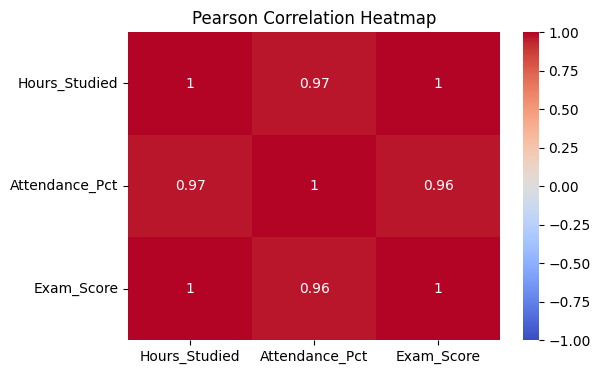

--- 2. REGRESSION ANALYSIS ---

A. Simple Linear Regression (Hours -> Score)
Equation: Score = 37.59 + (5.55 * Hours)
R-squared: 0.9910

B. Multiple Linear Regression (Hours + Attendance -> Score)
Equation: Score = 35.79 + (5.46 * Hours) + (0.03 * Attendance)
R-squared: 0.9910

C. Polynomial Regression (Degree 2) (Hours -> Score)
R-squared: 0.9976



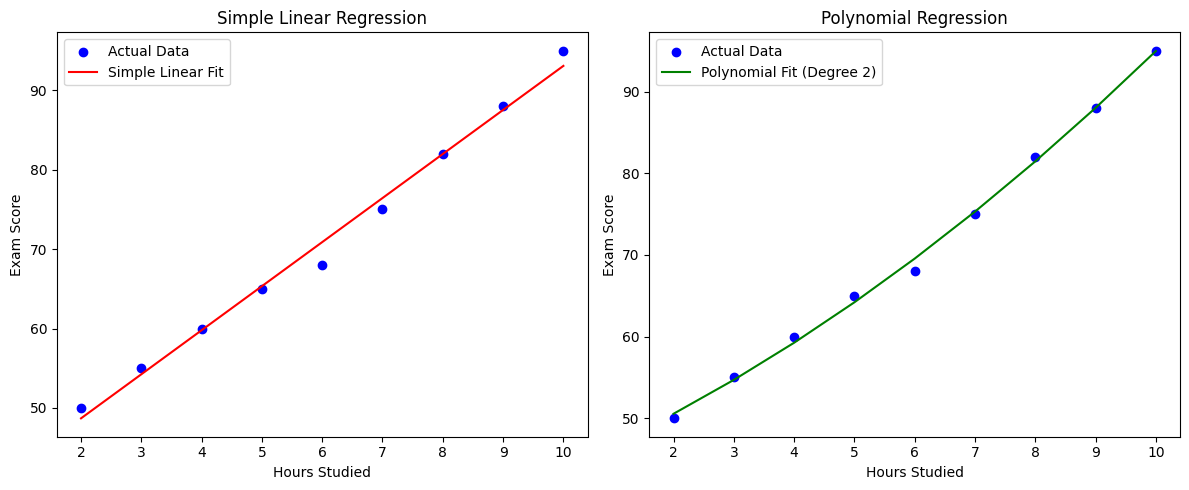

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# 1. Dataset Creation
# Adding a second independent variable (Attendance) for Multiple Regression
# ==========================================
data = {
    'Hours_Studied': [2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Attendance_Pct': [70, 75, 80, 85, 82, 90, 95, 92, 98],
    'Exam_Score': [50, 55, 60, 65, 68, 75, 82, 88, 95]
}
df = pd.DataFrame(data)

# ==========================================
# 2. STUDYING CORRELATION METHODS
# ==========================================
print("--- 1. CORRELATION ANALYSIS ---\n")

# A. Karl Pearson's Correlation (Evaluates linear relationship)
pearson_corr = df.corr(method='pearson')
print("Karl Pearson's Correlation Matrix:\n", pearson_corr, "\n")

# B. Spearman's Rank Correlation (Evaluates monotonic relationships / non-linear)
spearman_corr = df.corr(method='spearman')
print("Spearman's Rank Correlation Matrix:\n", spearman_corr, "\n")

# C. Kendall's Tau Correlation (Evaluates ordinal associations)
kendall_corr = df.corr(method='kendall')
print("Kendall's Tau Correlation Matrix:\n", kendall_corr, "\n")

# Visualization: Heatmap of Pearson Correlation
plt.figure(figsize=(6, 4))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap")
plt.show()

# ==========================================
# 3. STUDYING REGRESSION METHODS
# ==========================================
print("--- 2. REGRESSION ANALYSIS ---\n")

# Target variable (y)
y = df['Exam_Score']

# --- Method A: Simple Linear Regression (One Feature) ---
print("A. Simple Linear Regression (Hours -> Score)")
X_simple = df[['Hours_Studied']]
slr = LinearRegression()
slr.fit(X_simple, y)
y_pred_slr = slr.predict(X_simple)

print(f"Equation: Score = {slr.intercept_:.2f} + ({slr.coef_[0]:.2f} * Hours)")
print(f"R-squared: {r2_score(y, y_pred_slr):.4f}\n")

# --- Method B: Multiple Linear Regression (Multiple Features) ---
print("B. Multiple Linear Regression (Hours + Attendance -> Score)")
X_multi = df[['Hours_Studied', 'Attendance_Pct']]
mlr = LinearRegression()
mlr.fit(X_multi, y)
y_pred_mlr = mlr.predict(X_multi)

print(f"Equation: Score = {mlr.intercept_:.2f} + ({mlr.coef_[0]:.2f} * Hours) + ({mlr.coef_[1]:.2f} * Attendance)")
print(f"R-squared: {r2_score(y, y_pred_mlr):.4f}\n")

# --- Method C: Polynomial Regression (Non-linear pattern) ---
print("C. Polynomial Regression (Degree 2) (Hours -> Score)")
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_simple) # Transform X into 1, X, X^2
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)

print(f"R-squared: {r2_score(y, y_pred_poly):.4f}\n")

# ==========================================
# 4. VISUALIZING REGRESSION METHODS
# ==========================================
plt.figure(figsize=(12, 5))

# Plot 1: Simple Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(df['Hours_Studied'], y, color='blue', label='Actual Data')
plt.plot(df['Hours_Studied'], y_pred_slr, color='red', label='Simple Linear Fit')
plt.title('Simple Linear Regression')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()

# Plot 2: Polynomial Regression
plt.subplot(1, 2, 2)
plt.scatter(df['Hours_Studied'], y, color='blue', label='Actual Data')
# Sort values for a smooth polynomial curve
sorted_zip = sorted(zip(df['Hours_Studied'], y_pred_poly))
X_sorted, y_poly_sorted = zip(*sorted_zip)
plt.plot(X_sorted, y_poly_sorted, color='green', label='Polynomial Fit (Degree 2)')
plt.title('Polynomial Regression')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()

plt.tight_layout()
plt.show()

>Conclusion -

>This practical demonstrates different methods used to study correlation and regression between two variables. Karl Pearson's and Spearman methods measure the strength of relationship, while Simple Linear Regression helps predict dependent variable values using an independent variable. The regression graph visually represents the relationship between the data points and regression line.